# GW-Mamba — PEMS03 Traffic Forecasting
## Same architecture as PEMS08 baseline | Dataset-specific config only

| Property | Value |
|----------|-------|
| **Dataset** | PEMS03 |
| **Nodes** | 358 |
| **Channels** | 1 (Flow only (1 channel)) |
| **Timesteps** | 26,208 (5-min intervals) |
| **Batch size** | 32 |
| **d_model** | 80 |

### Published GWNet Baselines on PEMS03
| MAE | RMSE | MAPE |
|-----|------|------|
| 13 | 23 | 13.6% |

### Changes vs PEMS08 notebook
- `num_nodes` = 358
- `in_features` = 1  (1 channel — physics derivative makes F+1=2)
- `batch_size` = 32  (tuned for this dataset)
- `d_model` = 80
- Baseline targets updated to PEMS03 published values
- **PEMS03 special:** node ID remapping via PEMS03.txt (IDs are non-sequential integers like 313344)
- **Model architecture: unchanged** — GWNet backbone + Mamba refinement


In [1]:
!pip install einops --quiet

import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else '⚠  No GPU — switch to GPU runtime!')


Sat May 23 06:20:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, math, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    prop = torch.cuda.get_device_properties(0)
    print(f'  GPU  : {prop.name}')
    print(f'  VRAM : {prop.total_memory/1e9:.1f} GB')


Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


In [3]:
class Config:
    # ── Paths — update to your Kaggle input paths ─────────────────────────────
    data_path    = '/kaggle/input/datasets/piyusharma1617/pems03/PEMS03.npz'
    adj_csv_path = '/kaggle/input/datasets/piyusharma1617/pems03/PEMS03.csv'
    id_txt_path  = '/kaggle/input/datasets/piyusharma1617/pems03/PEMS03.txt'  # node ID list for adjacency remapping
    best_path    = 'gwmamba_pems03_best.pt'

    # ── Dataset — PEMS03-specific ─────────────────────────────────────────────
    num_nodes    = 358
    in_features  = 1       # flow only
    feature_idx  = 0           # always predict/evaluate on Flow (channel 0)
    seq_len      = 12          # PEMS03 standard: 12 × 5 min = 60 min input window
    pred_len     = 12          # 12 × 5 min = 60 min forecast horizon
    train_ratio  = 0.7
    val_ratio    = 0.1

    # ── GWNet backbone — unchanged architecture ────────────────────────────────
    d_model      = 80       # residual channels
    d_skip       = 256      # skip channels
    d_end        = 256      # MLP hidden dim
    d_time       = 64          # ToD + DoW embedding dim
    n_layers     = 8           # WaveBlocks  (dilations [1,2,4,8]×2)
    kernel_size  = 2           # TCN kernel (2 is standard for PEMS03/04/07)
    adp_emb      = 10          # adaptive adj node embedding dim
    gcn_order    = 2           # K-hop diffusion
    n_supports   = 3           # fwd + bwd + adaptive
    dropout      = 0.15

    # ── Mamba refinement — unchanged ──────────────────────────────────────────
    mamba_d_state = 8
    mamba_d_conv  = 2

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size   = 32        # tuned for PEMS03 (358 nodes)
    lr           = 1e-3
    warmup_eps   = 5
    epochs       = 50
    patience     = 20
    weight_decay = 1e-4
    grad_clip    = 3.0

    # ── Published baselines on PEMS03 (GWNet) ─────────────────────────────────
    baseline_mae  = 13
    baseline_rmse = 23
    baseline_mape = 13.6


cfg    = Config()
device = DEVICE
print(f'GW-Mamba | PEMS03 | d={cfg.d_model} d_skip={cfg.d_skip}')
print(f'  nodes={cfg.num_nodes}  in_features={cfg.in_features}  '
      f'seq={cfg.seq_len}→{cfg.pred_len}')
print(f'  batch={cfg.batch_size}  epochs={cfg.epochs}')
print(f'  Target baselines: MAE=14.57  RMSE=23.67  MAPE=16.04%')

# VRAM estimate
B, S, N, d = cfg.batch_size, cfg.seq_len, cfg.num_nodes, cfg.d_model
vram_est = B * d * N * S * 2 / 1e6 * cfg.n_layers   # fp16 activations
print(f'  VRAM estimate (activations only): ~{vram_est:.0f} MB')


GW-Mamba | PEMS03 | d=80 d_skip=256
  nodes=358  in_features=1  seq=12→12
  batch=32  epochs=50
  Target baselines: MAE=14.57  RMSE=23.67  MAPE=16.04%
  VRAM estimate (activations only): ~176 MB


In [4]:
def load_pems03(cfg):
    '''
    Load PEMS03 .npz, apply per-node Z-score (train set only).
    PEMS03 special: remaps non-sequential sensor IDs via PEMS03.txt.

    Returns
    -------
    data_normed : (T, N, F)
    data_raw    : (T, N, F)
    mean_np     : (N, F)    per-node mean  (train)
    std_np      : (N, F)    per-node std   (train)
    A_fwd, A_bwd: (N, N)
    n_train, n_val, n_test
    '''
    raw = np.load(cfg.data_path)['data'].astype(np.float32)   # (T, N, F)
    T, N, F = raw.shape
    print(f'Raw shape  : {raw.shape}')
    assert N == cfg.num_nodes, f'Expected {cfg.num_nodes} nodes, got {N}'

    n_train = int(T * cfg.train_ratio)
    n_val   = int(T * cfg.val_ratio)
    n_test  = T - n_train - n_val
    print(f'Split      : train={n_train}  val={n_val}  test={n_test}')

    tr       = raw[:n_train]
    mean_np  = tr.mean(axis=0)           # (N, F)
    std_np   = tr.std(axis=0) + 1e-8    # (N, F)
    data_normed = (raw - mean_np[None]) / std_np[None]

    fm = mean_np[:, cfg.feature_idx]
    fs = std_np [:, cfg.feature_idx]
    print(f'Flow norm  : mean [{fm.min():.1f}, {fm.max():.1f}]  '
          f'std [{fs.min():.2f}, {fs.max():.2f}]')

    # ── PEMS03 special: remap non-sequential node IDs via .txt file ───────────
    # Node IDs in PEMS03.csv are sensor hardware IDs (e.g. 313344, 313349...).
    # They must be mapped to 0-indexed row/col positions using PEMS03.txt,
    # which lists all 358 sensor IDs in the correct order.
    id2idx = {}
    if hasattr(cfg, 'id_txt_path') and os.path.exists(cfg.id_txt_path):
        with open(cfg.id_txt_path) as fid:
            raw_ids = [int(l.strip()) for l in fid if l.strip()]
        id2idx = {v: i for i, v in enumerate(raw_ids)}
        print(f'ID map loaded: {len(id2idx)} sensor IDs → 0-indexed')

    A_raw = np.zeros((N, N), dtype=np.float32)
    if os.path.exists(cfg.adj_csv_path):
        df = pd.read_csv(cfg.adj_csv_path)
        col_c = 'distance' if 'distance' in df.columns else ('cost' if 'cost' in df.columns else df.columns[2])
        mapped, skipped = 0, 0
        for _, r in df.iterrows():
            ri, rj, rc = int(r['from']), int(r['to']), float(r[col_c])
            # Remap sensor ID → matrix index if id2idx exists
            i = id2idx.get(ri, ri) if id2idx else ri
            j = id2idx.get(rj, rj) if id2idx else rj
            if 0 <= i < N and 0 <= j < N:
                A_raw[i, j] = rc; A_raw[j, i] = rc
                mapped += 1
            else:
                skipped += 1
        nz = A_raw[A_raw > 0]
        if len(nz) > 0:
            sigma  = nz.std() if nz.std() > 0 else 1.0
            A_raw  = np.exp(-(A_raw ** 2) / (sigma ** 2 + 1e-8))
        np.fill_diagonal(A_raw, 0.0)
        print(f'Adjacency: {int((A_raw > 0).sum())} edges ({mapped} mapped, {skipped} skipped)')
    else:
        A_raw = np.eye(N, dtype=np.float32)
        print('WARNING: CSV not found — identity adjacency')

    D_fwd = A_raw.sum(1, keepdims=True).clip(1e-8)
    D_bwd = A_raw.T.sum(1, keepdims=True).clip(1e-8)
    A_fwd = (A_raw   / D_fwd).astype(np.float32)
    A_bwd = (A_raw.T / D_bwd).astype(np.float32)
    return data_normed, raw, mean_np, std_np, A_fwd, A_bwd, n_train, n_val, n_test


In [5]:
class PEMSDataset(Dataset):
    '''
    Generic PEMS sliding-window dataset.
    Works for any number of input channels (F=1 or F=3).

    Physics-informed temporal derivative is appended as an extra channel,
    giving F+1 input channels in total.

    Returns per sample:
        x_feat  : (S, N, F+1)     normalised features + derivative
        y_normed: (pred_len, N)   normalised flow targets
        y_raw   : (pred_len, N)   raw flow targets
        tod_idx : (S,)             time-of-day [0..287]
        dow_idx : (S,)             day-of-week [0..6]
    '''
    def __init__(self, data_normed, data_raw, feature_idx,
                 seq_len, pred_len, start_ts=0, tod_slots=288):
        super().__init__()
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.start_ts = start_ts
        self.tod_slots= tod_slots

        flow_n   = data_normed[:, :, feature_idx:feature_idx+1]
        diff     = np.zeros_like(flow_n)
        diff[1:] = flow_n[1:] - flow_n[:-1]
        self.features   = np.concatenate([data_normed, diff], axis=-1)  # (T,N,F+1)
        self.flow_normed= data_normed[:, :, feature_idx]
        self.flow_raw   = data_raw   [:, :, feature_idx]
        self.length     = len(data_normed) - seq_len - pred_len + 1

    def __len__(self): return self.length

    def __getitem__(self, idx):
        s, e     = idx, idx + self.seq_len
        x_feat   = self.features   [s:e]
        y_normed = self.flow_normed[e:e+self.pred_len]
        y_raw    = self.flow_raw   [e:e+self.pred_len]
        ts       = np.arange(self.start_ts+s, self.start_ts+e)
        tod_idx  = (ts % self.tod_slots).astype(np.int64)
        dow_idx  = (ts // self.tod_slots % 7).astype(np.int64)
        return (torch.from_numpy(x_feat).float(),
                torch.from_numpy(y_normed).float(),
                torch.from_numpy(y_raw).float(),
                torch.from_numpy(tod_idx),
                torch.from_numpy(dow_idx))


def build_dataloaders(cfg):
    data_normed, data_raw, mean_np, std_np, A_fwd, A_bwd, \
        n_train, n_val, n_test = load_pems03(cfg)

    mean_flow = torch.tensor(mean_np[:,cfg.feature_idx], dtype=torch.float32, device=device)
    std_flow  = torch.tensor(std_np [:,cfg.feature_idx], dtype=torch.float32, device=device)
    A_fwd_t   = torch.tensor(A_fwd, dtype=torch.float32)
    A_bwd_t   = torch.tensor(A_bwd, dtype=torch.float32)

    ds_kw = dict(feature_idx=cfg.feature_idx, seq_len=cfg.seq_len,
                 pred_len=cfg.pred_len)
    tr_ds = PEMSDataset(data_normed[:n_train],            data_raw[:n_train],
                        start_ts=0,            **ds_kw)
    va_ds = PEMSDataset(data_normed[n_train:n_train+n_val],
                        data_raw[n_train:n_train+n_val],  start_ts=n_train, **ds_kw)
    te_ds = PEMSDataset(data_normed[n_train+n_val:],      data_raw[n_train+n_val:],
                        start_ts=n_train+n_val, **ds_kw)

    lkw = dict(batch_size=cfg.batch_size, num_workers=4,
               pin_memory=True, drop_last=False)
    dl_tr = DataLoader(tr_ds, shuffle=True,  **lkw)
    dl_va = DataLoader(va_ds, shuffle=False, **lkw)
    dl_te = DataLoader(te_ds, shuffle=False, **lkw)

    print(f'Batches    : train={len(dl_tr)}  val={len(dl_va)}  test={len(dl_te)}')
    xb, yn, yr, tb, db = next(iter(dl_tr))
    print(f'x_feat     : {xb.shape}  (F+1 = {cfg.in_features}+1 = {cfg.in_features+1})')
    print(f'y_raw range: [{yr.min():.1f}, {yr.max():.1f}]')
    return dl_tr, dl_va, dl_te, mean_flow, std_flow, A_fwd_t, A_bwd_t


dl_train, dl_val, dl_test, mean_flow, std_flow, A_fwd_t, A_bwd_t = \
    build_dataloaders(cfg)


Raw shape  : (26208, 358, 1)
Split      : train=18345  val=2620  test=5243
Flow norm  : mean [19.2, 407.4]  std [14.51, 211.37]
ID map loaded: 358 sensor IDs → 0-indexed
Adjacency: 127806 edges (547 mapped, 0 skipped)
Batches    : train=573  val=82  test=164
x_feat     : torch.Size([32, 12, 358, 2])  (F+1 = 1+1 = 2)
y_raw range: [0.0, 1160.0]


In [6]:
class DiffusionGCN(nn.Module):
    '''K-hop diffusion GCN. Identical to PEMS08 version.'''
    def __init__(self, d_in, d_out, n_supports=3, order=2, dropout=0.15):
        super().__init__()
        self.order = order
        total_in   = d_in * (1 + n_supports * order)
        self.mlp   = nn.Linear(total_in, d_out)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, supports):
        hs = [x]
        for A in supports:
            h = x
            for _ in range(self.order):
                h = torch.einsum('nm,bmd->bnd', A, h)
                hs.append(h)
        return self.drop(self.mlp(torch.cat(hs, dim=-1)))


class WaveBlock(nn.Module):
    '''Gated dilated TCN + Diffusion GCN. Identical to PEMS08 version.'''
    def __init__(self, d_model, d_skip, kernel_size, dilation,
                 n_supports, gcn_order, dropout):
        super().__init__()
        self.dilation    = dilation
        self.kernel_size = kernel_size
        conv_kw = dict(kernel_size=(1, kernel_size), dilation=(1, dilation))
        self.filter_conv = nn.Conv2d(d_model, d_model, **conv_kw)
        self.gate_conv   = nn.Conv2d(d_model, d_model, **conv_kw)
        self.gcn         = DiffusionGCN(d_model, d_model, n_supports,
                                        gcn_order, dropout)
        self.bn          = nn.BatchNorm2d(d_model)
        self.drop        = nn.Dropout(dropout)
        self.skip_conv   = nn.Conv2d(d_model, d_skip,  (1, 1))
        self.res_conv    = nn.Conv2d(d_model, d_model, (1, 1))

    def forward(self, x, supports):
        B, d, N, S = x.shape
        residual   = x
        pad        = (self.kernel_size - 1) * self.dilation
        x_pad      = F.pad(x, [pad, 0])
        f = torch.tanh   (self.filter_conv(x_pad))
        g = torch.sigmoid(self.gate_conv  (x_pad))
        x = self.drop(f * g)
        xg = x.permute(0,3,2,1).reshape(B*S, N, d)
        xg = self.gcn(xg, supports)
        x  = xg.reshape(B,S,N,d).permute(0,3,2,1)
        x  = self.bn(x)
        skip = self.skip_conv(x)
        x    = self.res_conv(x) + residual
        return x, skip

print('DiffusionGCN + WaveBlock defined.')


DiffusionGCN + WaveBlock defined.


In [7]:
class SelectiveSSM(nn.Module):
    '''Discretised selective SSM. Identical to PEMS08 version.'''
    def __init__(self, d_inner: int, d_state: int = 8):
        super().__init__()
        self.d_state = d_state
        A = torch.arange(1, d_state+1, dtype=torch.float32)\
                  .unsqueeze(0).expand(d_inner,-1)
        self.log_A   = nn.Parameter(torch.log(A).clone())
        self.proj_BC = nn.Linear(d_inner, 2*d_state, bias=False)
        self.proj_dt = nn.Linear(d_inner, d_inner,   bias=True)
        self.D       = nn.Parameter(torch.ones(d_inner))
        self.softplus= nn.Softplus()

    def forward(self, x):
        BN, T, d = x.shape
        N  = self.d_state
        dt = self.softplus(self.proj_dt(x))
        BC = self.proj_BC(x)
        B_, C_ = BC[..., :N], BC[..., N:]
        A_neg  = -torch.exp(self.log_A.float())
        dA_bar = torch.exp(torch.einsum('btd,dn->btdn', dt, A_neg))
        dB_bar = torch.einsum('btd,bts->btds', dt, B_)
        h = x.new_zeros(BN, d, N)
        ys = []
        for t in range(T):
            h   = dA_bar[:,t]*h + dB_bar[:,t]*x[:,t,:].unsqueeze(-1)
            y_t = (h * C_[:,t,:].unsqueeze(1)).sum(-1)
            ys.append(y_t)
        return torch.stack(ys, dim=1) + x * self.D


class MambaRefinementBlock(nn.Module):
    '''Lightweight Mamba on skip accumulation. Identical to PEMS08 version.'''
    def __init__(self, d_model, d_state=8, d_conv=2):
        super().__init__()
        self.norm     = nn.LayerNorm(d_model)
        self.in_proj  = nn.Linear(d_model, d_model*2, bias=False)
        self.conv1d   = nn.Conv1d(d_model, d_model, d_conv,
                                  groups=d_model, padding=d_conv-1, bias=True)
        self.ssm      = SelectiveSSM(d_model, d_state)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.drop     = nn.Dropout(0.1)

    def forward(self, x):
        B, D, N, S = x.shape
        residual    = x
        h  = x.permute(0,2,3,1).reshape(B*N, S, D)
        h  = self.norm(h)
        xz = self.in_proj(h)
        z, g = xz.chunk(2, dim=-1)
        z    = z.permute(0,2,1)
        z    = self.conv1d(z)[...,:S]
        z    = F.silu(z.permute(0,2,1))
        z    = self.ssm(z)
        out  = z * F.silu(g)
        out  = self.drop(self.out_proj(out))
        out  = out.reshape(B,N,S,D).permute(0,3,1,2)
        return out + residual

print('SelectiveSSM + MambaRefinementBlock defined.')


SelectiveSSM + MambaRefinementBlock defined.


In [8]:
class GWMamba(nn.Module):
    '''GW-Mamba model. Architecture IDENTICAL to PEMS08 baseline.'''
    def __init__(self, cfg):
        super().__init__()
        self.d_skip   = cfg.d_skip
        self.n_layers = cfg.n_layers
        N = cfg.num_nodes

        self.E1 = nn.Parameter(torch.randn(N, cfg.adp_emb) * 0.01)
        self.E2 = nn.Parameter(torch.randn(N, cfg.adp_emb) * 0.01)

        # in_features + 1 (physics derivative appended in Dataset)
        self.start_conv = nn.Conv2d(cfg.in_features + 1, cfg.d_model, (1, 1))
        self.node_emb   = nn.Parameter(torch.randn(1, cfg.d_model, N, 1) * 0.01)

        self.tod_emb   = nn.Embedding(288, cfg.d_time)
        self.dow_emb   = nn.Embedding(7,   cfg.d_time)
        self.time_proj = nn.Linear(cfg.d_time * 2, cfg.d_model)

        dilations = [1, 2, 4, 8, 1, 2, 4, 8][:cfg.n_layers]
        self.blocks = nn.ModuleList([
            WaveBlock(cfg.d_model, cfg.d_skip, cfg.kernel_size, d,
                      cfg.n_supports, cfg.gcn_order, cfg.dropout)
            for d in dilations
        ])

        self.mamba_refine = MambaRefinementBlock(
            cfg.d_skip, cfg.mamba_d_state, cfg.mamba_d_conv)

        self.end_conv1 = nn.Conv2d(cfg.d_skip, cfg.d_end,    (1, 1))
        self.end_conv2 = nn.Conv2d(cfg.d_end,  cfg.pred_len, (1, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
        nn.init.normal_(self.tod_emb.weight, std=0.01)
        nn.init.normal_(self.dow_emb.weight, std=0.01)

    def register_adj(self, A_fwd, A_bwd):
        self.register_buffer('A_fwd', A_fwd)
        self.register_buffer('A_bwd', A_bwd)

    def get_supports(self):
        A_adp = F.softmax(F.relu(self.E1 @ self.E2.T), dim=-1)
        return [self.A_fwd, self.A_bwd, A_adp]

    def forward(self, x, _=None, tod=None, dow=None):
        x = x.permute(0, 3, 2, 1)
        x = self.start_conv(x) + self.node_emb
        if tod is not None and dow is not None:
            te = torch.cat([self.tod_emb(tod), self.dow_emb(dow)], dim=-1)
            te = self.time_proj(te).permute(0,2,1).unsqueeze(2)
            x  = x + te
        supports = self.get_supports()
        skip_sum = torch.zeros(x.size(0), self.d_skip, x.size(2), x.size(3),
                               device=x.device, dtype=x.dtype)
        for block in self.blocks:
            x, skip  = block(x, supports)
            skip_sum = skip_sum + skip
        skip_ref = F.relu(skip_sum)
        skip_ref = self.mamba_refine(skip_ref)
        out = skip_ref[:,:,:,-4:].mean(-1, keepdim=True)
        out = F.relu(self.end_conv1(out))
        out = self.end_conv2(out)
        return out.squeeze(-1)


set_seed()
model = GWMamba(cfg).to(device)
model.register_adj(A_fwd_t.to(device), A_bwd_t.to(device))

total   = sum(p.numel() for p in model.parameters() if p.requires_grad)
buffers = sum(b.numel() for b in model.buffers())
print(f'GWMamba ready  — {total:,} trainable params  {buffers:,} buffer params')

model.eval()
with torch.no_grad():
    _x   = torch.randn(2, cfg.seq_len, cfg.num_nodes, cfg.in_features+1).to(device)
    _tod = torch.randint(0, 288, (2, cfg.seq_len)).to(device)
    _dow = torch.randint(0, 7,   (2, cfg.seq_len)).to(device)
    with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
        _out = model(_x, None, _tod, _dow)
ok = list(_out.shape) == [2, cfg.pred_len, cfg.num_nodes]
print(f'Dry-run output: {_out.shape}  {"✓" if ok else "✗ CHECK"}')
assert ok
model.train()
del _x, _tod, _dow, _out
torch.cuda.empty_cache()


GWMamba ready  — 1,188,324 trainable params  257,616 buffer params
Dry-run output: torch.Size([2, 12, 358])  ✓


In [9]:
def masked_mae(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return (torch.abs(pred-true)*mask).sum() / (mask.sum()+1e-8)

def masked_huber(pred, true, delta=1.0, null_val=0.0):
    mask = (true != null_val).float()
    err  = torch.abs(pred-true)
    loss = torch.where(err<delta, 0.5*err**2, delta*(err-0.5*delta))
    return (loss*mask).sum() / (mask.sum()+1e-8)

def masked_rmse(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return torch.sqrt(((pred-true)**2*mask).sum()/(mask.sum()+1e-8))

def masked_mape(pred, true, low_thresh=10.0):
    '''Standard PEMS benchmark protocol: mask |true| < low_thresh.'''
    mask = (true.abs() > low_thresh).float()
    if mask.sum() < 1: return torch.tensor(0.0, device=pred.device)
    ape  = torch.abs((pred-true)/(true.abs()+1.0))
    return (ape*mask).sum()/mask.sum()*100.0


class CurriculumLoss:
    def __init__(self, warmup_eps=5, delta=1.0):
        self.warmup_eps = warmup_eps
        self.delta      = delta
        self.epoch      = 1
    def update(self, ep): self.epoch = ep
    @property
    def phase(self): return 'huber' if self.epoch<=self.warmup_eps else 'mae'
    def __call__(self, pred, true):
        if self.phase == 'huber': return masked_huber(pred, true, self.delta)
        return masked_mae(pred, true)


criterion = CurriculumLoss(warmup_eps=cfg.warmup_eps)
print('Metrics + CurriculumLoss defined.')


Metrics + CurriculumLoss defined.


In [10]:
set_seed()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=cfg.lr, weight_decay=cfg.weight_decay,
                               betas=(0.9, 0.95))

def lr_lambda(epoch):
    if epoch < cfg.warmup_eps: return (epoch+1)/cfg.warmup_eps
    return 1.0

warmup_sched  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
cosine_sched  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=1, eta_min=5e-5)
plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5, min_lr=5e-5)

amp_scaler    = torch.amp.GradScaler('cuda', enabled=device.type=='cuda')
print(f'Optimiser ready  lr={cfg.lr}  wd={cfg.weight_decay}')


Optimiser ready  lr=0.001  wd=0.0001


In [11]:
def train_epoch(model, loader, optimizer, device):
    model.train(); total = 0.0
    for batch in loader:
        x, y_norm, y_raw, tod, dow = batch
        x     = x.to(device,    non_blocking=True)
        y_raw = y_raw.to(device, non_blocking=True)
        tod   = tod.to(device,  non_blocking=True)
        dow   = dow.to(device,  non_blocking=True)
        with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
            pred_n = model(x, None, tod=tod, dow=dow)
            pred_r = pred_n * std_flow[None,None,:] + mean_flow[None,None,:]
            loss   = criterion(pred_r, y_raw)
        optimizer.zero_grad(set_to_none=True)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        amp_scaler.step(optimizer); amp_scaler.update()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval(); maes, rmses, mapes = [], [], []
    for batch in loader:
        x, y_norm, y_raw, tod, dow = batch
        x     = x.to(device,    non_blocking=True)
        y_raw = y_raw.to(device, non_blocking=True)
        tod   = tod.to(device,  non_blocking=True)
        dow   = dow.to(device,  non_blocking=True)
        with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
            pred_n = model(x, None, tod=tod, dow=dow)
        pred_r = pred_n.float() * std_flow[None,None,:] + mean_flow[None,None,:]
        maes.append( masked_mae  (pred_r, y_raw).item())
        rmses.append(masked_rmse (pred_r, y_raw).item())
        mapes.append(masked_mape (pred_r, y_raw).item())
    return float(sum(maes)/len(maes)), float(sum(rmses)/len(rmses)), float(sum(mapes)/len(mapes))

print('train_epoch + eval_epoch defined.')


train_epoch + eval_epoch defined.


In [12]:
best_val_mae = float('inf')
patience_cnt = 0
history      = {'train_loss':[], 'val_mae':[], 'val_rmse':[], 'val_mape':[]}

BL_MAE  = cfg.baseline_mae
BL_RMSE = cfg.baseline_rmse
BL_MAPE = cfg.baseline_mape

print('=' * 78)
print(f'  GW-Mamba  |  PEMS03  |  {device}  |  batch={cfg.batch_size}')
print(f'  Baseline (GWNet) → MAE={BL_MAE}  RMSE={BL_RMSE}  MAPE={BL_MAPE}%')
print('=' * 78)
print(f'{"Ep":>4} | {"Phase":>5} | {"Loss":>8} | {"MAE":>7} | '
      f'{"RMSE":>7} | {"MAPE":>7} | {"LR":>8} | {"Sec":>5}')
print('-' * 78)

for epoch in range(1, cfg.epochs+1):
    criterion.update(epoch); t0 = time.time()
    train_loss = train_epoch(model, dl_train, optimizer, device)
    val_mae, val_rmse, val_mape = eval_epoch(model, dl_val, device)

    if epoch <= cfg.warmup_eps: warmup_sched.step()
    else: cosine_sched.step(epoch - cfg.warmup_eps)
    plateau_sched.step(val_mae)

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_mape'].append(val_mape)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    tag = ''; beat = ''
    if val_mae < best_val_mae:
        best_val_mae = val_mae; patience_cnt = 0
        torch.save(model.state_dict(), cfg.best_path)
        tag = ' ← ✓'
    else: patience_cnt += 1

    if val_mae < BL_MAE and val_rmse < BL_RMSE and val_mape < BL_MAPE:
        beat = '  🎯 ALL 3 BEAT!'
    elif val_mae < BL_MAE:
        beat = '  ✅ MAE BEAT'

    if epoch % 5 == 0 or tag or beat:
        print(f'{epoch:>4} | {criterion.phase:>5} | {train_loss:>8.4f} | '
              f'{val_mae:>7.3f} | {val_rmse:>7.3f} | {val_mape:>6.2f}% | '
              f'{lr_now:>8.2e} | {elapsed:>4.0f}s{tag}{beat}')

    if patience_cnt >= cfg.patience:
        print(f'\nEarly stop at epoch {epoch} (patience={cfg.patience})')
        break

print('=' * 78)
print(f'Best Val MAE : {best_val_mae:.3f}  (baseline {BL_MAE})')
if best_val_mae < BL_MAE:
    print(f'🎯 MAE baseline beaten by {BL_MAE - best_val_mae:.3f}!')


  GW-Mamba  |  PEMS03  |  cuda  |  batch=32
  Baseline (GWNet) → MAE=13  RMSE=23  MAPE=13.6%
  Ep | Phase |     Loss |     MAE |    RMSE |    MAPE |       LR |   Sec
------------------------------------------------------------------------------
   1 | huber |  24.2070 |  18.766 |  26.900 |  15.16% | 4.00e-04 |  662s ← ✓
   2 | huber |  16.6565 |  16.093 |  23.486 |  14.00% | 6.00e-04 |  671s ← ✓
   3 | huber |  15.8059 |  15.240 |  22.537 |  12.07% | 8.00e-04 |  671s ← ✓
   5 | huber |  15.1579 |  16.081 |  23.537 |  13.76% | 1.00e-03 |  671s
   6 |   mae |  15.1620 |  14.762 |  22.080 |  11.56% | 9.99e-04 |  671s ← ✓
   8 |   mae |  14.5763 |  14.618 |  21.849 |  11.66% | 9.92e-04 |  670s ← ✓
   9 |   mae |  14.3402 |  14.502 |  21.643 |  11.61% | 9.85e-04 |  670s ← ✓
  10 |   mae |  14.2241 |  14.266 |  21.497 |  11.40% | 9.77e-04 |  670s ← ✓
  13 |   mae |  13.7647 |  14.253 |  21.439 |  11.34% | 9.41e-04 |  671s ← ✓
  14 |   mae |  13.6339 |  14.128 |  21.289 |  11.11% | 9.26e-04 |

In [13]:
model.load_state_dict(torch.load(cfg.best_path, map_location=device))
print(f'Loaded checkpoint  (val MAE={best_val_mae:.3f})')

test_mae, test_rmse, test_mape = eval_epoch(model, dl_test, device)

print()
print('=' * 52)
print('  GW-MAMBA  —  PEMS03  TEST SET RESULTS')
print('=' * 52)
for name_m, val, base, unit in [
    ('MAE',  test_mae,  cfg.baseline_mae,  ''),
    ('RMSE', test_rmse, cfg.baseline_rmse, ''),
    ('MAPE', test_mape, cfg.baseline_mape, '%'),
]:
    diff   = val - base
    symbol = '✅ BEAT' if diff < 0 else '❌'
    print(f'  {name_m:<5}: {val:>8.3f}{unit}  '
          f'(baseline {base:.3f}{unit}  Δ={diff:+.3f})  {symbol}')
print('=' * 52)


Loaded checkpoint  (val MAE=13.785)

  GW-MAMBA  —  PEMS03  TEST SET RESULTS
  MAE  :   14.880  (baseline 13.000  Δ=+1.880)  ❌
  RMSE :   23.834  (baseline 23.000  Δ=+0.834)  ❌
  MAPE :   11.826%  (baseline 13.600%  Δ=-1.774)  ✅ BEAT


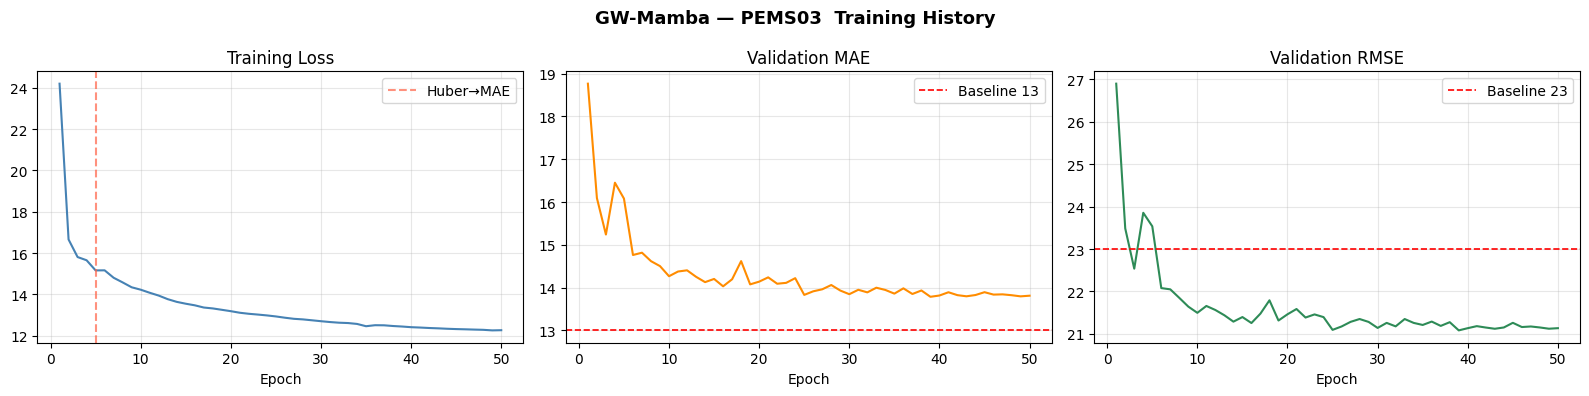

Saved → pems03_curves.png


In [14]:
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('GW-Mamba — PEMS03  Training History', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(ep, history['train_loss'], color='steelblue', lw=1.5)
ax.axvline(cfg.warmup_eps, color='tomato', ls='--', alpha=0.7, label='Huber→MAE')
ax.set_title('Training Loss'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

for ax, key, title, base, c in zip(
    axes[1:],
    ['val_mae', 'val_rmse'],
    ['Validation MAE', 'Validation RMSE'],
    [cfg.baseline_mae, cfg.baseline_rmse],
    ['darkorange', 'seagreen']
):
    ax.plot(ep, history[key], color=c, lw=1.5)
    ax.axhline(base, color='red', ls='--', lw=1.2, label=f'Baseline {base}')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pems03_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pems03_curves.png')


 Step |      MAE |     RMSE |    MAPE%
──────────────────────────────────────
    1 |  12.7201 |  21.2431 |    9.99%
    2 |  13.3574 |  22.7736 |   10.42%
    3 |  13.8982 |  24.0056 |   10.79%
    4 |  14.3022 |  24.9645 |   11.05%
    5 |  14.6407 |  25.7283 |   11.30%
    6 |  14.9282 |  26.2961 |   11.50%
    7 |  15.2408 |  26.8243 |   11.73%
    8 |  15.5746 |  27.3147 |   12.00%
    9 |  15.8146 |  27.7177 |   12.15%
   10 |  16.0398 |  28.1394 |   12.32%
   11 |  16.3243 |  28.5861 |   12.57%
   12 |  16.5268 |  28.8785 |   12.74%


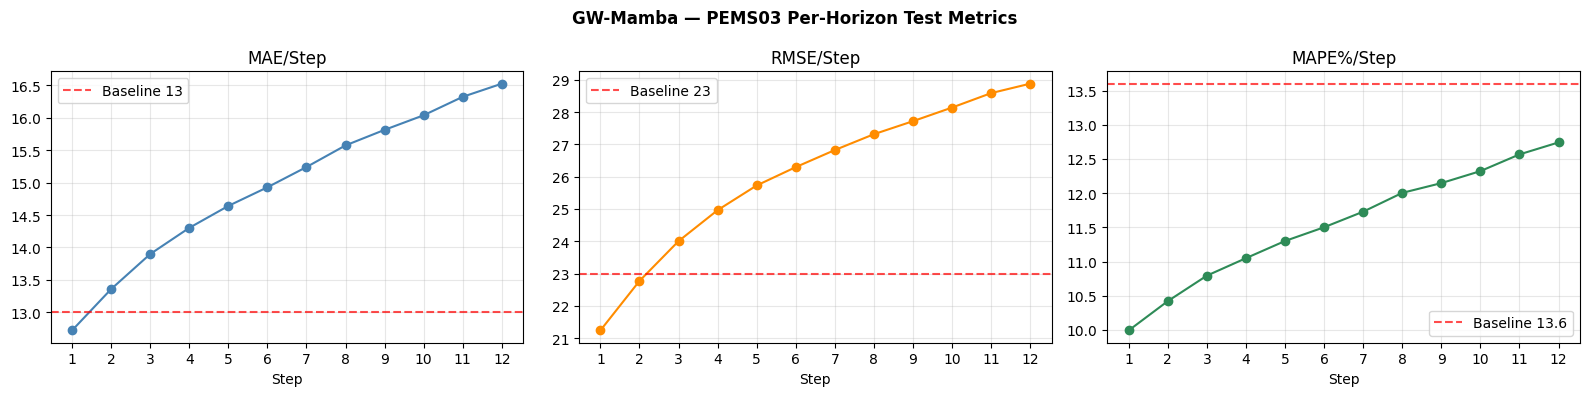

In [15]:
@torch.no_grad()
def horizon_eval(model, loader, device):
    model.eval(); all_p, all_t = [], []
    for batch in loader:
        x, _, y_raw, tod, dow = batch
        x     = x.to(device,    non_blocking=True)
        y_raw = y_raw.to(device, non_blocking=True)
        tod   = tod.to(device,  non_blocking=True)
        dow   = dow.to(device,  non_blocking=True)
        with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
            pred_n = model(x, None, tod=tod, dow=dow)
        pred_r = pred_n.float() * std_flow[None,None,:] + mean_flow[None,None,:]
        all_p.append(pred_r.cpu()); all_t.append(y_raw.cpu())
    P = torch.cat(all_p); T_ = torch.cat(all_t)
    rows = []
    for h in range(cfg.pred_len):
        p, t = P[:,h], T_[:,h]
        rows.append((h+1, masked_mae(p,t).item(),
                     masked_rmse(p,t).item(), masked_mape(p,t).item()))
    return rows

hrows = horizon_eval(model, dl_test, device)
print(f'{"Step":>5} | {"MAE":>8} | {"RMSE":>8} | {"MAPE%":>8}')
print('─' * 38)
for step, mae, rmse, mape in hrows:
    print(f'{step:>5} | {mae:>8.4f} | {rmse:>8.4f} | {mape:>7.2f}%')

steps = [r[0] for r in hrows]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('GW-Mamba — PEMS03 Per-Horizon Test Metrics', fontweight='bold')
for ax, vals, title, base, c in zip(
    axes,
    [[r[1] for r in hrows], [r[2] for r in hrows], [r[3] for r in hrows]],
    ['MAE/Step','RMSE/Step','MAPE%/Step'],
    [cfg.baseline_mae, cfg.baseline_rmse, cfg.baseline_mape],
    ['steelblue','darkorange','seagreen']
):
    ax.plot(steps, vals, marker='o', color=c, lw=1.5)
    ax.axhline(base, color='red', ls='--', alpha=0.7, label=f'Baseline {base}')
    ax.set_xticks(steps); ax.set_xlabel('Step')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pems03_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
